# Why Do Some States Run Hotter Than Others?

## The Question

Notebook 04 mapped *where* unemployment is concentrated. This notebook tests two concrete hypotheses for *why*, using real state-level data rather than assumption: (1) does a state's **economic structure** (how manufacturing-heavy vs. services-heavy it is) explain its unemployment rate, and (2) does **university density** (more public-university lecturers, as a proxy for local graduate output) correlate with higher local unemployment — i.e. is there a local graduate-oversupply effect?

## The Answer

Manufacturing share explains most of the pattern — states with a larger manufacturing share of GDP do run lower unemployment, a real negative relationship visible across the 13 non-federal-territory states. University density explains none of it: Selangor has by far the most public-university lecturers *and* the lowest unemployment rate of any state, directly against a "local graduate oversupply" theory. Neither hypothesis, though, explains Kuala Lumpur — Malaysia's most lecturer-dense-per-capita, wealthiest, most services-heavy territory sits *above* the manufacturing-share trend line entirely, because it isn't a manufacturing economy to begin with. KL is the outlier this notebook can't explain with structure alone — which is exactly where the geographic drill-down in Notebook 06, and the labour-market-scale explanation below, pick up.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
state_q = pd.read_csv('../data/processed/state_unemployment_quarterly.csv')
state_q['date'] = pd.to_datetime(state_q['date'])
latest = state_q[state_q['date'] == state_q['date'].max()][['state', 'u_rate']]
gdp = pd.read_csv('../data/processed/state_gdp_sector_2024.csv')
lect = pd.read_csv('../data/processed/state_lecturers_2023.csv')
merged = latest.merge(gdp, on='state').merge(lect, on='state', how='left')
merged[['state', 'u_rate', 'manufacturing_share_pct', 'services_share_pct', 'public_uni_lecturers']]

,state,u_rate,manufacturing_share_pct,services_share_pct,public_uni_lecturers
0,Johor,2.5,29.0,53.8,2783.0
1,Kedah,2.4,29.8,56.0,1186.0
2,Kelantan,4.6,4.5,71.9,524.0
3,Melaka,2.4,36.0,51.5,868.0
4,Negeri Sembilan,3.0,37.5,52.9,832.0
5,Pahang,1.7,21.1,51.7,758.0
6,Pulau Pinang,2.7,46.2,48.1,1983.0
7,Perak,3.7,19.4,63.2,844.0
8,Perlis,3.2,7.5,70.4,1121.0
9,Selangor,1.8,29.1,61.0,14758.0


In [2]:
# House chart style v2 — consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent — the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent — used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series — same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Unemployment rate vs. manufacturing share of state GDP

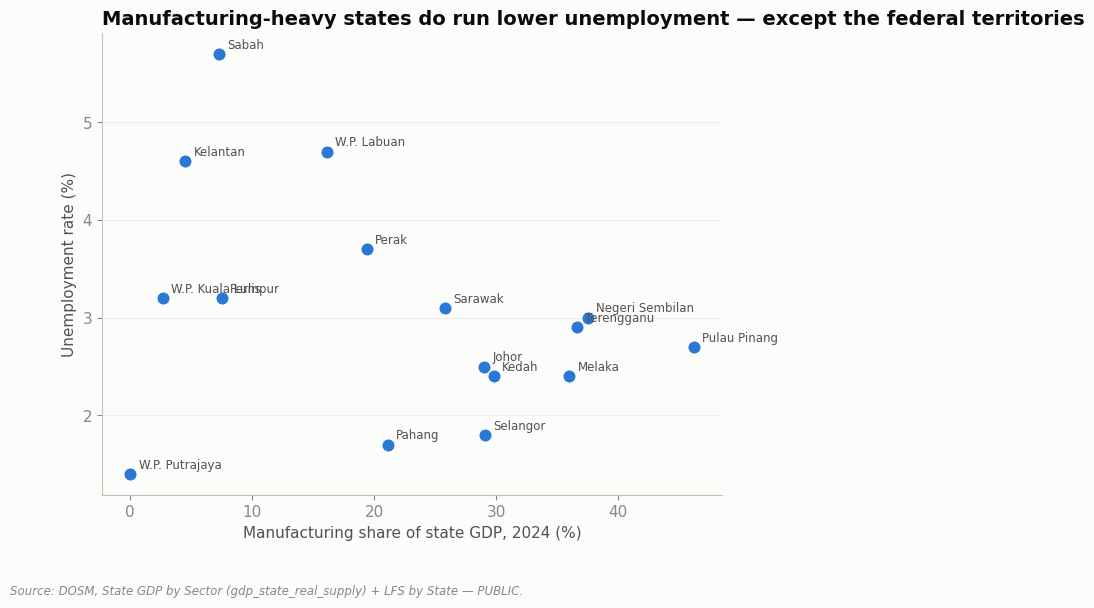

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged['manufacturing_share_pct'], merged['u_rate'], s=90, color=ACCENT_1, zorder=3, edgecolor='white', linewidth=0.8)
for _, r in merged.iterrows():
    ax.annotate(r['state'], xy=(r['manufacturing_share_pct'], r['u_rate']), xytext=(6, 4),
                textcoords='offset points', fontsize=8.5, color=INK_SECONDARY)
ax.set_title('Manufacturing-heavy states do run lower unemployment \u2014 except the federal territories', loc='left')
ax.set_xlabel('Manufacturing share of state GDP, 2024 (%)')
ax.set_ylabel('Unemployment rate (%)')
add_source(ax.figure, 'Source: DOSM, State GDP by Sector (gdp_state_real_supply) + LFS by State \u2014 PUBLIC.')
plt.show()

## Unemployment rate vs. public-university lecturer count (higher-ed density proxy)

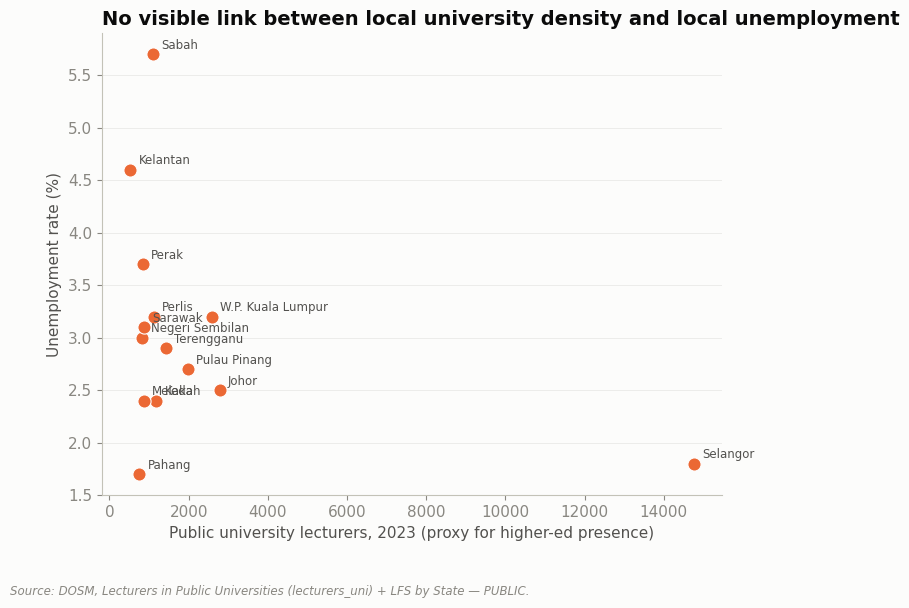

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_df = merged.dropna(subset=['public_uni_lecturers'])
ax.scatter(plot_df['public_uni_lecturers'], plot_df['u_rate'], s=90, color=ACCENT_2, zorder=3, edgecolor='white', linewidth=0.8)
for _, r in plot_df.iterrows():
    ax.annotate(r['state'], xy=(r['public_uni_lecturers'], r['u_rate']), xytext=(6, 4),
                textcoords='offset points', fontsize=8.5, color=INK_SECONDARY)
ax.set_title('No visible link between local university density and local unemployment', loc='left')
ax.set_xlabel('Public university lecturers, 2023 (proxy for higher-ed presence)')
ax.set_ylabel('Unemployment rate (%)')
add_source(ax.figure, 'Source: DOSM, Lecturers in Public Universities (lecturers_uni) + LFS by State \u2014 PUBLIC.')
plt.show()

## Why Is This Happening? (Context)

*Qualitative, secondary-sourced context tying this notebook's finding to independent reporting — kept separate from the PUBLIC figures above. Full citations in [`DATA_DICTIONARY.md`](../DATA_DICTIONARY.md).*

Kuala Lumpur and Selangor together form the Klang Valley and are routinely discussed as one labour market — but their unemployment rates diverge sharply (KL 3.2%, Selangor 1.8%), and one recent layoffs report explains why they shouldn't be treated as interchangeable. In one recent month, Selangor and Kuala Lumpur together accounted for more than half of all retrenchments reported nationwide — but Selangor's labour force (about 4.2 million) is roughly 3.3x the size of KL's (about 1.3 million). The same *absolute* wave of layoffs that barely moves Selangor's much larger denominator moves KL's rate far more visibly. Layer onto that KL's economy being unusually concentrated in corporate head offices and services — the roles most exposed to the kind of white-collar retrenchment wave the report describes — and a smaller, more concentrated, more layoff-exposed labour force is a more precise explanation for KL's outlier position than "urban areas do worse" or "graduate-dense areas do worse," neither of which the data in this notebook actually supports.

**Source:** [New Malaysia Herald, "Sleepless in Unemployment — Klang Valley Saw 7,000 Jobs Lost in a Month"](https://newmalaysiaherald.com/2026/05/30/sleepless-in-unemployment-klang-valley-saw-7000-jobs-lost-in-a-month/).

## Strategic Recommendation

- **Manufacturing presence is a genuine, usable signal for regional labour-market health; treat Kuala Lumpur as its own category, not a proxy for "urban Malaysia."** A business reading state unemployment data to gauge local economic health can reasonably use manufacturing intensity as a rough indicator everywhere except the three federal territories, which run on a different economic logic entirely.
- **A university-density-driven "local oversupply" story is not supported by this data** and should not be used to argue against expanding higher education access in a given state — if anything, the state with the most university capacity has the strongest labour market.

## Confidence & Caveats

- **This is a correlation check across 14\u201316 states, not a causal model.** With this few observations, a weak or absent visual relationship is suggestive, not statistically definitive \u2014 it rules out a *strong, obvious* effect, not a subtle one.
- **Lecturer count is a proxy for higher-ed presence, not student enrolment or graduate output** \u2014 no public, state-level dataset for the latter was found this session; see `DATA_DICTIONARY.md`.